# OOF Evaluation — Diagnostics


## 1. Imports and Configuration


In [1]:
# Core libraries
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

MODEL_ID = 'gam'
RUN_NAME = "nusc_mini_debug_tpp-11_Mar_2026_15_29_02"
TARGET_COL = None  # Optional override, e.g. 'ml_ade_log'

RESULTS_ROOT = Path('../../results/interpretable_model') / MODEL_ID / RUN_NAME
TABLES_DIR = RESULTS_ROOT / 'tables'
PLOTS_DIR = RESULTS_ROOT / 'plots'

print(f'Results root: {RESULTS_ROOT.resolve()}')
print(f'Model ID: {MODEL_ID}')
print(f'Run: {RUN_NAME}')
print(f'TARGET_COL override: {TARGET_COL}')


Results root: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02
Model ID: gam
Run: nusc_mini_debug_tpp-11_Mar_2026_15_29_02
TARGET_COL override: None


## 2. Load Run Manifest and Nested-Resampling Artifacts


In [2]:
def resolve_manifest_path(model_id, run_name, target_col=None):
    manifest_dir = Path('../../results/interpretable_model') / model_id / run_name / 'tables'
    if not manifest_dir.exists():
        raise FileNotFoundError(f'No tables directory found for model_id={model_id}, run_name={run_name}: {manifest_dir}')

    if target_col is not None:
        manifest_path = manifest_dir / f'run_manifest_{target_col}.json'
        if not manifest_path.exists():
            raise FileNotFoundError(f'Run manifest not found for target_col={target_col}: {manifest_path}')
        return manifest_path

    manifest_candidates = sorted(manifest_dir.glob('run_manifest_*.json'))
    if not manifest_candidates:
        raise FileNotFoundError(f'No run_manifest_*.json files found in {manifest_dir}')
    if len(manifest_candidates) > 1:
        raise ValueError(
            f'Multiple run manifests found in {manifest_dir}. Set TARGET_COL explicitly. '
            f'Candidates: {[p.name for p in manifest_candidates]}'
        )
    return manifest_candidates[0]


manifest_path = resolve_manifest_path(MODEL_ID, RUN_NAME, TARGET_COL)
manifest = json.loads(manifest_path.read_text())

if manifest['model_id'] != MODEL_ID:
    raise ValueError(f"Manifest model_id={manifest['model_id']} does not match MODEL_ID={MODEL_ID}")

target_col = manifest['target_col']
feature_cols = manifest['feature_cols']
TABLES_DIR = Path(manifest['tables_dir'])
PLOTS_DIR = Path(manifest['plots_dir'])
POOR_WELL_QUANTILE = manifest['analysis'].get('poor_well_quantile', 0.20)

nested_resampling = manifest['nested_resampling']
model_data_path = Path(nested_resampling['model_data_with_oof_path'])
metrics_path = Path(nested_resampling['oof_metrics_path'])

model_df_oof = pd.read_csv(model_data_path)
oof_metrics_df = pd.read_csv(metrics_path)

X = model_df_oof[feature_cols]
y_oof_orig = model_df_oof['target_orig'].to_numpy()
y_oof_pred_orig = model_df_oof['oof_pred_orig'].to_numpy()

print(f'Loaded manifest: {manifest_path}')
print(f'Loaded model data: {model_data_path}')
print(f'Loaded OOF metrics: {metrics_path}')
print(f'Target: {target_col} | Features: {len(feature_cols)}')
display(oof_metrics_df)


Loaded manifest: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/run_manifest_ml_ade_log.json
Loaded model data: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/model_data_with_oof_ml_ade_log.csv
Loaded OOF metrics: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/metrics_oof_ml_ade_log.csv
Target: ml_ade_log | Features: 13


,Split,R²,MAE,RMSE
0,OOF,0.54506,0.287759,0.392494


## 3. Model-Fit Diagnostics (OOF)


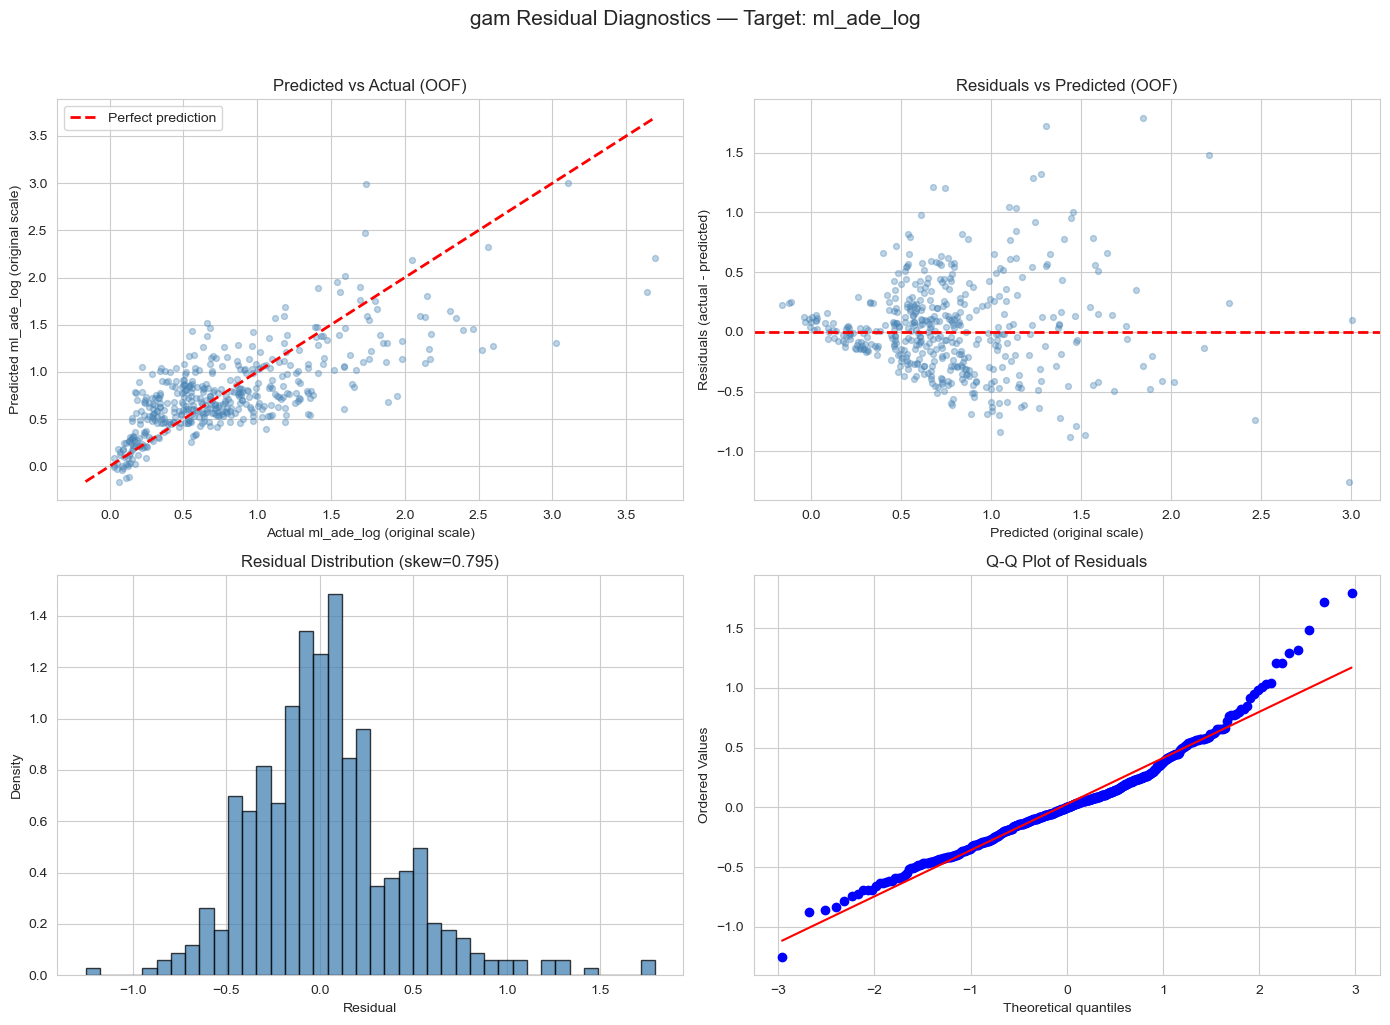

Diagnostics plot saved to: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots/residual_diagnostics_oof_ml_ade_log.png
Residual mean:   0.026522
Residual median: 0.000693
Residual std:    0.391596


In [3]:
residuals_oof = y_oof_orig - y_oof_pred_orig

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(y_oof_orig, y_oof_pred_orig, alpha=0.35, s=18, color='steelblue')
lims = [
    min(np.min(y_oof_orig), np.min(y_oof_pred_orig)),
    max(np.max(y_oof_orig), np.max(y_oof_pred_orig)),
]
axes[0, 0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0, 0].set_xlabel(f'Actual {target_col} (original scale)')
axes[0, 0].set_ylabel(f'Predicted {target_col} (original scale)')
axes[0, 0].set_title('Predicted vs Actual (OOF)')
axes[0, 0].legend()

axes[0, 1].scatter(y_oof_pred_orig, residuals_oof, alpha=0.35, s=18, color='steelblue')
axes[0, 1].axhline(0.0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted (original scale)')
axes[0, 1].set_ylabel('Residuals (actual - predicted)')
axes[0, 1].set_title('Residuals vs Predicted (OOF)')

axes[1, 0].hist(residuals_oof, bins=40, density=True, alpha=0.75, color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title(f'Residual Distribution (skew={stats.skew(residuals_oof):.3f})')

stats.probplot(residuals_oof, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals')

plt.suptitle(f'{MODEL_ID} Residual Diagnostics — Target: {target_col}', fontsize=15, y=1.02)
plt.tight_layout()
diag_path = PLOTS_DIR / f'residual_diagnostics_oof_{target_col}.png'
plt.savefig(diag_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Diagnostics plot saved to: {diag_path}')
print(f'Residual mean:   {residuals_oof.mean():.6f}')
print(f'Residual median: {np.median(residuals_oof):.6f}')
print(f'Residual std:    {residuals_oof.std():.6f}')


## 4. Saved Artifacts


In [4]:
print("Saved artifacts:")
print(f"- Run manifest:      {manifest_path}")
print(f"- OOF metrics table: {metrics_path}")
print(f"- Diagnostics plot:  {diag_path}")
print(f"- Plot directory:    {PLOTS_DIR}")


Saved artifacts:
- Run manifest:      ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/run_manifest_ml_ade_log.json
- OOF metrics table: ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/metrics_oof_ml_ade_log.csv
- Diagnostics plot:  ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots/residual_diagnostics_oof_ml_ade_log.png
- Plot directory:    ../../results/interpretable_model/gam/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots
